# 02. Paper: Transformers Can Do Bayesian Inference

원 논문: Müller, Hollmann, Pineda Arango, Grabocka, Hutter, *Transformers Can Do Bayesian Inference* (2021), [arXiv:2112.10510](https://arxiv.org/abs/2112.10510). 이 저장소 이름의 근간이 되는 **PFN(Prior-Data Fitted Networks)** 원 논문입니다.

chapter 01에서 우리는 PFN이 근사하려는 대상인 **posterior predictive distribution(PPD)** 을 만났습니다.

$$
p(y \mid x, D) \;=\; \int p(y \mid x, \theta)\; p(\theta \mid D)\; d\theta
$$

문제는 이 적분이 일반적으로 **닫힌형으로 안 풀린다**는 것입니다. MCMC·변분추론(VI)은 이 적분을 근사하지만, **데이터셋 $D$가 바뀔 때마다 처음부터 다시** 계산해야 합니다.

PFN의 도약은 이겁니다:

> PPD $p(y \mid x, D)$ 자체가 $(x, D)$의 **함수**다. 그렇다면 그 함수를 **한 번** 신경망으로 학습해두고, 추론 때는 forward pass 한 번으로 예측을 뽑으면 되지 않을까?

이 논문 학습은 두 세션으로 진행합니다. **이 노트북은 세션 1(이론)** 으로, 그 아이디어를 논문 순서대로 1~5절까지 풀어봅니다.

1. 재구성 — "PPD를 계산" 대신 "PPD를 학습"
2. **task와 데이터셋 구성** — 논문은 무엇을 샘플링하는가
3. 학습 목적함수와 그것이 왜 PPD로 수렴하는가 (KL 논증)
4. 동전 예제로 KL 논증을 수치로 확인 (chapter 01 연결)
5. **prior-fitting 루프** — prior가 곧 학습 데이터

이어지는 **구현 디테일(6~7절)과 세션 2 재현 준비(8~9절)** 는 다음 노트북 [`03_pfn_implementation_details.ipynb`](03_pfn_implementation_details.ipynb) 로 옮겼습니다.

6. 회귀 출력 표현: Riemann / bar distribution → `03`
7. 아키텍처: Transformer encoder, set 처리, attention 마스킹 → `03`
8. GP prior 집중 — 세션 2 재현 대상의 정답 → `03`
9. 요약과 세션 2로의 다리 → `03`

## `pfn_cookbook` 불러오기

chapter 01과 동일하게, 로컬에서는 설치된 패키지를, Databricks처럼 미설치 환경에서는 `src/`를 import 경로에 추가합니다.

In [7]:
try:
    import pfn_cookbook
except ImportError:
    import sys
    from pathlib import Path

    sys.path.insert(0, str(Path.cwd().parent / "src"))

In [8]:
import matplotlib.pyplot as plt
import numpy as np

from pfn_cookbook import set_seed

set_seed(0)  # 재현성을 위해 난수 시드를 고정한다.

## 1. 핵심 — "PPD를 계산" 하는 대신 "PPD를 학습" 한다.

핵심 관찰: **PPD는 $(x, D)$를 입력받아 예측분포를 내놓는 함수**입니다.

$$
q_\theta(y \mid x, D) \;\approx\; p(y \mid x, D)
$$

여기서 $\theta$는 이제 (베이지안 파라미터가 아니라) **신경망의 가중치**입니다. 만약 prior에서 데이터셋을 마음껏 샘플링할 수 있다면, $(D,\ x,\ y)$ 삼중쌍을 무한히 만들어 **지도학습**으로 $q_\theta$를 훈련시킬 수 있습니다.

- **입력**: 학습 셋 $D = \{(x_i, y_i)\}_{i=1}^{n}$ 와 쿼리 지점 $x$
- **출력**: 쿼리 라벨 $y$에 대한 **예측분포**
- **정답 신호**: prior에서 함께 뽑은 실제 $y$

MCMC/VI가 데이터셋마다 추론을 다시 하는 것과 달리, PFN은 **한 번 학습**하면 그 prior에서 나온 **모든 데이터셋에 재사용**됩니다. 이것이 *amortized inference*(분할상환 추론)입니다.

## 2. task와 데이터셋 구성 — 논문은 무엇을 샘플링하는가

PFN 학습의 재료는 prior에서 뽑은 데이터셋입니다. 그렇다면 **task**가 뭐고 그 데이터셋이 어떻게 만들어지는지, 논문의 Algorithm 1 을 정리합니다.

논문에서 표준 베이지안 예측을 이렇게 씁니다. 여기서 $t$가 **task**(잠재 변수, latent variable)입니다.

$$
p(y \mid x, D) = \int_{t} p(y \mid x, t)\; p(t \mid D)\; dt \tag{Eq.\,1}
$$

**task $t$** 는 데이터를 만들어내는 **하나의 가설(hypothesis)·메커니즘·함수**입니다. prior $p(t)$는 "있을 법한 task들"에 대한 믿음입니다.

- 동전 던지기 task = 편향 $\theta$를 가진 **동전 하나**
- GP prior task = GP에서 뽑은 **함수 $f$ 하나**
- BNN prior task = 가중치가 정해진 **신경망 하나**

**PFN의 트릭**: 논문은 $p(t)$나 $p(t \mid D)$를 명시적으로 모델링하지 않습니다. 필요한 건 **데이터셋 prior $p(D)$에서 샘플을 뽑는 능력**뿐입니다. task $t$는 데이터셋을 만드는 과정에 잠깐 쓰이고 적분되어 사라지는 잠재 변수입니다.

$$
p(D) = \int_{t} p(D \mid t)\; p(t)\; dt
$$

Task 는 논문에서 사용하는 데이터 단위를 말합니다. 이 데이터셋이 모델에 들어가는 모습이 논문 Figure 1(a)입니다.

표와 같은 구성(context $n=3$, query $m=2$)으로, context 쌍 $(x_1,y_1)(x_2,y_2)(x_3,y_3)=D$ 와 query $x_4, x_5$가 각각 토큰으로 들어가고, 각 query 위치에서 예측분포 $q(\cdot\mid x_4,D),\ q(\cdot\mid x_5,D)$가 나옵니다.  
query의 $y$는 입력에 없다는 점(표의 NaN)이 그림에서도 $x_4, x_5$ 아래에 $y$가 없는 것으로 드러납니다.

![PFN Figure 1(a)](images/pfn_fig1a.png)

*그림: 논문 Figure 1(a) (Müller et al. 2021, [arXiv:2112.10510](https://arxiv.org/abs/2112.10510)). 화살표는 attention 흐름 — 파랑은 context 토큰끼리, 빨강은 각 query가 context에만 attend (attention 마스킹의 자세한 규칙은 7절).*

### 데이터 예시

같은 데이터셋을 표로 보면 구조가 분명해집니다.

논문 Figure 1(a)와 같은 구성(context $n=3$, query $m=2$)으로 하나 만들어, 먼저 샘플된 원본을 보고 그다음 **모델 입력 뷰**를 봅니다.  
입력 뷰에서 query 행의 $y$는 가려지며(NaN), 모델은 바로 이 값을 예측하도록 학습됩니다.

In [ ]:
import pandas as pd
from IPython.display import display


# task = 무작위 사인 함수 (진폭·주파수·위상을 prior에서 뽑는다)
def sample_task(rng):
    amp = rng.uniform(0.5, 2.0)
    freq = rng.uniform(0.5, 1.5)
    phase = rng.uniform(0, 2 * np.pi)
    return lambda x: amp * np.sin(freq * x + phase)


# 논문 Figure 1(a)와 같은 구성: context n=3, query m=2
rng = np.random.default_rng(1)
n, m = 3, 2
task = sample_task(rng)
x = rng.uniform(-5, 5, size=n + m)
y = task(x) + 0.1 * rng.standard_normal(n + m)
role = ["context"] * n + ["query"] * m

df = pd.DataFrame({"i": range(1, n + m + 1), "x": x.round(3), "y": y.round(3), "role": role})
print("샘플된 데이터셋 (D = context 3개 + query 2개):")
display(df)

# 모델에 들어가는 형태 — query의 y는 가려진다(NaN). 이 y를 맞히도록 학습한다.
df_input = df.copy()
df_input.loc[df_input["role"] == "query", "y"] = np.nan
print("모델 입력 뷰 — query 라벨은 가려짐 (이 값을 예측):")
display(df_input)

### Algorithm 1: 데이터셋 하나를 만드는 절차
이제 위와 같은 형태의 데이터를 학습 스텝마다 **데이터셋 하나** 를 샘플링합니다.

1. **task를 뽑는다**: $t \sim p(t)$ — 함수/메커니즘 하나
2. **입력을 뽑는다**: $x_1, \dots, x_N$
3. **라벨을 뽑는다**: 각 $x_i$에 대해 $y_i \sim p(y \mid x_i, t)$

이렇게 얻은 $N = n + m$개 점을 **context $n$개**와 **query $m$개**로 나눕니다.

- **context** $D = \{(x_i, y_i)\}_{i=1}^{n}$ → 모델에 그대로 입력 (in-context)
- **query** $\{(x_j, y_j)\}_{j=n+1}^{N}$ → 라벨을 가리고 예측시켜 NLL 계산

한 데이터셋에서 **여러 query를 동시에** 학습에 씁니다 (한 점씩이 아니라). context 크기 $n$은 매 스텝 랜덤하게 골라, 데이터가 거의 없을 때부터 많을 때까지 두루 학습됩니다. 아래에서 task=무작위 사인 함수로 데이터셋 하나가 어떻게 구성되는지 눈으로 봅니다.

In [ ]:
# 데이터셋 하나를 만드는 절차(task 샘플 → 입력 샘플 → 라벨 샘플)를 한 축에 그린다
def draw_one_dataset(ax, rng, N=20, n=12):
    task = sample_task(rng)  # (1) prior에서 task 하나
    x = rng.uniform(-5, 5, size=N)  # (2) 입력 샘플
    y = task(x) + 0.1 * rng.standard_normal(N)  # (3) 라벨 (+ 관측 노이즈)
    ctx, qry = np.arange(n), np.arange(n, N)  # set이라 순서 무관 — 앞 n개 context, 나머지 query

    grid = np.linspace(-5, 5, 300)
    ax.plot(grid, task(grid), color="gray", lw=1, label="task (hidden function t)")
    ax.scatter(x[ctx], y[ctx], c="C0", s=45, label=f"context (n={n})")
    ax.scatter(
        x[qry],
        y[qry],
        facecolors="none",
        edgecolors="C3",
        s=70,
        label=f"query (m={N - n}, label hidden)",
    )
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.legend(fontsize=8)


# 서로 다른 시드 → prior에서 매번 다른 task가 뽑힌다는 것을 두 패널로 보여준다
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2), sharey=True)
for ax, seed in zip(axes, [0, 7], strict=True):
    draw_one_dataset(ax, np.random.default_rng(seed))
    ax.set_title(f"Dataset from prior sample (seed={seed})")
fig.suptitle("Each draw from the prior gives a different task -> inputs -> labels")
plt.show()

## 3. 학습 목적함수 — 왜 PPD로 수렴하는가

학습 손실은 쿼리 라벨의 **음의 로그가능도(NLL)** 를, prior에서 뽑은 데이터셋에 대해 평균낸 것입니다.

$$
\mathcal{L}(\theta) \;=\; \mathbb{E}_{D,\,(x,y)\sim p}\big[\,-\log q_\theta(y \mid x, D)\,\big]
$$

여기서 $(x, y)$와 $D$는 **같은 prior에서** 뽑힙니다. 이 손실을 최소화하면 왜 진짜 PPD가 나올까요?  
고정된 $(x, D)$에 대해, $y$가 진짜 PPD $p(y\mid x,D)$를 따를 때의 기대 NLL은 **교차 엔트로피**이고 다음처럼 분해됩니다.

$$
\mathbb{E}_{y\sim p(\cdot\mid x,D)}\big[-\log q_\theta(y\mid x,D)\big]
= \underbrace{H\big(p(\cdot\mid x,D)\big)}_{\theta\text{와 무관}}
+ \; \mathrm{KL}\!\big(p(\cdot\mid x,D)\;\|\;q_\theta(\cdot\mid x,D)\big)
$$

첫 항은 $\theta$와 무관한 상수(진짜 PPD의 엔트로피)입니다. 따라서 **기대 NLL을 최소화하는 것은 PPD와 $q_\theta$ 사이의 KL을 최소화하는 것과 정확히 같고**, KL은 $q_\theta = p(\cdot\mid x,D)$일 때 0이 됩니다.  
즉,

$$
\arg\min_\theta \mathcal{L}(\theta) \;\;\Longrightarrow\;\; q_\theta(y\mid x, D) = p(y \mid x, D).
$$

**충분한 용량과 데이터가 있으면, NLL로 학습된 PFN은 진짜 베이지안 PPD로 수렴합니다.**  
이것이 논문의 핵심 이론적 근거입니다. 다음 셀에서 이 주장을 수치로 눈으로 확인합니다.

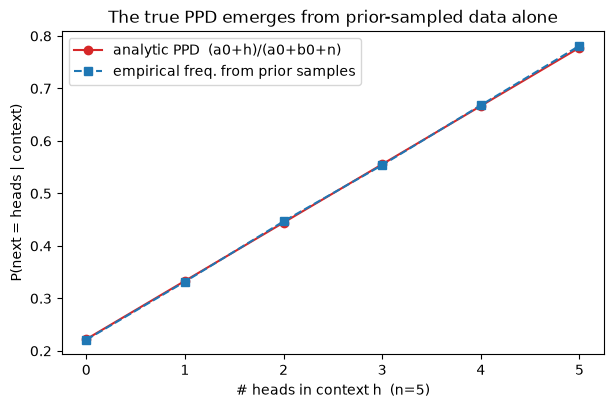

최대 절대 오차: 0.0034839132061353917


In [11]:
a0, b0 = 2.0, 2.0  # prior: Beta(2, 2)
n = 5  # context 크기 (동전을 n번 던져 관측)
n_tasks = 400_000  # prior에서 뽑는 task 수

thetas = np.random.beta(a0, b0, size=n_tasks)  # (1) θ ~ prior
ctx = (np.random.rand(n_tasks, n) < thetas[:, None]).astype(int)  # (2) context n flips
query = (np.random.rand(n_tasks) < thetas).astype(int)  # (3) 마스킹된 쿼리 라벨

h = ctx.sum(axis=1)  # 충분통계량: context 속 앞면 수

# 같은 context(같은 h)끼리 묶어 쿼리 라벨의 경험적 평균 = 데이터가 말해주는 PPD
emp = np.array([query[h == k].mean() for k in range(n + 1)])
ppd = (a0 + np.arange(n + 1)) / (a0 + b0 + n)  # 베이지안 닫힌형 PPD

fig, ax = plt.subplots(figsize=(7, 4.2))
ax.plot(range(n + 1), ppd, "o-", color="C3", label="analytic PPD  (a0+h)/(a0+b0+n)")
ax.plot(range(n + 1), emp, "s--", color="C0", label="empirical freq. from prior samples")
ax.set_xlabel(f"# heads in context h  (n={n})")
ax.set_ylabel("P(next = heads | context)")
ax.set_title("The true PPD emerges from prior-sampled data alone")
ax.legend()
plt.show()

print("최대 절대 오차:", np.max(np.abs(emp - ppd)))

## 5. prior-fitting 루프 — prior가 곧 학습 데이터

2절의 "데이터셋 하나 만들기"를 매 스텝 반복하고 gradient를 적용하면 논문의 **Algorithm 1**이 됩니다.

```latex
θ 초기화                                       # θ = 신경망 가중치
반복(step마다):
    D ∪ {(x_i, y_i)}_{i=1..m}  ~  p(D)          # 2절 절차로 데이터셋 하나 (context D + query m개)
    ℓ̄(θ) = Σ_{i=1..m}  −log q_θ(y_i | x_i, D)   # 모든 query 점의 NLL 합
    θ ← θ − η ∇θ ℓ̄(θ)                           # gradient step
```

특징:

- **실제 데이터는 한 번도 쓰지 않습니다.** prior가 곧 학습 분포입니다 — 그래서 이름이 *Prior-Data Fitted*.
- prior의 질이 전부입니다. "이 prior에서 나올 법한 데이터셋"에 대해서만 잘 예측합니다.
- 학습이 끝난 $q_\theta$는 그 prior에서 나온 **어떤 데이터셋에도** forward pass 한 번으로 대응합니다. 실제 학습셋 $D$는 **추론 시점에** 입력 시퀀스로 넣어줄 뿐, 가중치 업데이트는 없습니다 (*in-context learning*).